In [2]:
import yasa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

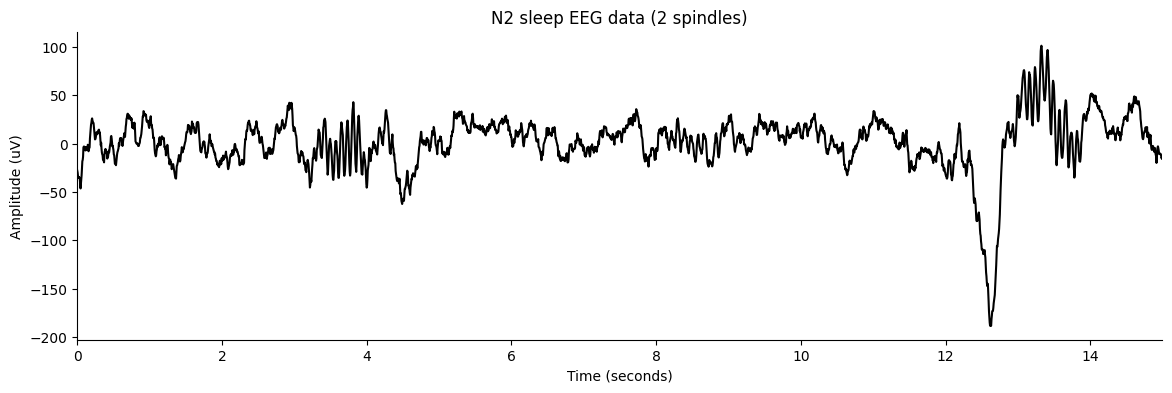

In [3]:
# Download the data
filepath = yasa.fetch_sample('N2_spindles_15sec_200Hz.txt')

# Load data
data = np.loadtxt(filepath)

# Define sampling frequency and time vector
sf = 200.
times = np.arange(data.size) / sf

# Plot the signal
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(times, data, lw=1.5, color='k')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([times.min(), times.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [4]:
# Apply the detection using yasa.spindles_detect
sp = yasa.spindles_detect(data, sf)

# Display the results using .summary()
sp.summary()

,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Channel,IdxChannel
0,3.31,3.815,4.06,0.75,82.649913,56.762908,19.408260,2.717369,0.497468,12.853460,10.0,0.668874,CHAN000,0
1,13.25,13.410,13.84,0.59,99.115345,62.683793,24.528229,2.834379,0.238997,12.155747,7.0,0.268908,CHAN000,0


In [11]:
import io
import contextlib
import traceback
import argparse
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import mne
from scipy.signal import hilbert, butter, sosfiltfilt
from scipy.fft import next_fast_len
from joblib import Parallel, delayed
from tqdm.auto import tqdm

try:
    import bottleneck as bn
    _HAS_BOTTLENECK = True
except ImportError:
    _HAS_BOTTLENECK = False


# =============================================================================
# SECTIE 1 — CONFIGURATIE
# =============================================================================

# ── Mappen ────────────────────────────────────────────────────────────────────
RAW_ROOT   = Path(r"\\vs03.herseninstituut.knaw.nl\VS03-SandC-2\raw\bnbd\Data\eeg")
GROUPS     = ["NSR", "Prezens", "SAV"]   # de drie te doorzoeken groepsmappen
EVENTS_DIR = Path(r"C:\Users\zafar\Documents\THESIS_OUTPUTS\2_candidate_events")
EVENTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Kanaalnamen intern (wat Phase 9 verwacht) → EDF bestandsnaam ──────────────
# EEG L en R worden twee keer ingeladen:
#   psg-lp  → krijgt EEG bandpass (0.1–35 Hz)
#   psg-emg → krijgt EMG bandpass (10–100 Hz)
CHANNEL_FILES = {
    "EEG L psg-lp":  "EEG L",
    "EEG R psg-lp":  "EEG R",
    "EEG L psg-emg": "EEG L",
    "EEG R psg-emg": "EEG R",
    "dX":            "dX",
    "dY":            "dY",
    "dZ":            "dZ",
}

CH_F7    = "EEG L psg-lp"
CH_F8    = "EEG R psg-lp"
CH_EMG_L = "EEG L psg-emg"
CH_EMG_R = "EEG R psg-emg"
EEG_CH   = [CH_F7, CH_F8]
EMG_CH   = [CH_EMG_L, CH_EMG_R]
MOV_CH   = ["dX", "dY", "dZ"]
ALL_CH   = EEG_CH + EMG_CH + MOV_CH

# ── Preprocessing parameters ──────────────────────────────────────────────────
TARGET_SFREQ          = 128
NOTCH_HZ              = 50.0
EEG_L_FREQ            = 0.1
EEG_H_FREQ            = 35.0
EMG_L_FREQ            = 10.0
EMG_H_FREQ            = 100.0
MOVEMENT_THRESHOLD_UV = 1000.0

# ── Frequentiebanden ──────────────────────────────────────────────────────────
BANDS = {
    "theta": (4.0,  7.0),
    "alpha": (8.0,  12.0),
    "sigma": (12.0, 16.0),
    "beta":  (16.0, 30.0),
}

# ── Signaalverwerking ─────────────────────────────────────────────────────────
SMOOTH_SEC           = 0.5
BASELINE_SEC         = 90.0    # Popovic gebruikte 90 s
ACTIVATION_THRESHOLD = 2.0
SPINDLE_THRESHOLD    = 2.0
MERGE_GAP_SEC        = 1.0
MIN_DUR_SEC          = 1.0
MAX_DUR_SEC          = 15.0

# ── Wake mask ─────────────────────────────────────────────────────────────────
WAKE_THRESHOLD_MULT  = 2.5
WAKE_MIN_DUR_SEC     = 20.0

# ── Post-event wake check ─────────────────────────────────────────────────────
POST_EVENT_CHECK_SEC = 15.0
POST_EVENT_WAKE_FRAC = 0.5

# ── REM gate ──────────────────────────────────────────────────────────────────
REM_EMG_SUPPRESSION_FRAC = 0.8

N_JOBS = -1

# ── Hypnogram ─────────────────────────────────────────────────────────────────
# Rechtschaffen & Kales codering
STAGE_WAKE = 0
STAGE_REM  = 5   # R&K gebruikt 5 voor REM, niet 4 (AASM)
EPOCH_SEC  = 30  # standaard PSG epoch lengte in seconden

# Bestandsstructuur hypnogram:
#   RAW_ROOT / GROUP / subject_id / stem / sleepArchitecture / stem.csv
# Voorbeeld:
#   .../NSR/bnbd_nsr_03554/bnbd_nsr_03554_T0_N1/sleepArchitecture/
#       bnbd_nsr_03554_T0_N1.csv


# =============================================================================
# SECTIE 2 — MAPPENSTRUCTUUR
# =============================================================================

def find_night_dirs(raw_root: Path) -> list:
    """
    Zoekt alle *_edf mappen onder de drie groepsmappen (NSR, Prezens, SAV).

    Structuur:
      raw_root / GROUP / bnbd_xxx_XXXXX / bnbd_xxx_XXXXX_T0_N1 /
          bnbd_xxx_XXXXX_T0_N1_edf /    ← dit zoeken we
              EEG L.edf
              EEG R.edf
              ...

    Geeft gesorteerde lijst van *_edf Path objecten.
    """
    edf_dirs = []
    for group in GROUPS:
        group_path = raw_root / group
        if not group_path.exists():
            continue
        edf_dirs.extend(
            d for d in group_path.rglob("*_edf")
            if d.is_dir() and "_T0_" in d.name
        )
    return sorted(edf_dirs)


def parse_ids(edf_dir: Path) -> dict:
    """
    Parseert IDs uit de naam van de *_edf map.

    .../NSR/bnbd_nsr_01272/bnbd_nsr_01272_T0_N2/bnbd_nsr_01272_T0_N2_edf
    → subject_id = bnbd_nsr_01272
    → night_id   = T0_N2
    → group      = NSR
    → stem       = bnbd_nsr_01272_T0_N2
    """
    stem  = edf_dir.name.replace("_edf", "")   # "bnbd_nsr_01272_T0_N2"
    parts = stem.split("_")                     # ["bnbd","nsr","01272","T0","N2"]
    return {
        "subject_id": "_".join(parts[:3]),      # bnbd_nsr_01272
        "night_id":   "_".join(parts[3:]),      # T0_N2
        "group":      parts[1].upper(),         # NSR
        "stem":       stem,
    }


def get_csv_path(ids: dict) -> Path:
    return (
        EVENTS_DIR
        / ids["group"]
        / ids["subject_id"]
        / f"candidate_events_{ids['subject_id']}_{ids['night_id']}.csv"
    )


def get_hypnogram_path(ids: dict) -> Path:
    """
    Berekent het hypnogram pad.

    Structuur:
      RAW_ROOT / GROUP / subject_id / stem / sleepArchitecture / stem.csv

    Voorbeeld:
      .../NSR/bnbd_nsr_01272/bnbd_nsr_01272_T0_N2/
          sleepArchitecture/bnbd_nsr_01272_T0_N2.csv
    """
    return (
        RAW_ROOT
        / ids["group"]
        / ids["subject_id"]
        / ids["stem"]
        / "sleepArchitecture"
        / f"{ids['stem']}.csv"
    )


# =============================================================================
# SECTIE 3 — LADEN EN PREPROCESSING
# Losse EDF bestanden laden, samenvoegen in geheugen, preprocessing toepassen.
# Geeft signals dict terug: kanaalnaam → 1D numpy array (µV), plus sfreq.
# =============================================================================

def load_and_preprocess(night_dir: Path) -> dict:
    """
    Laadt losse EDF kanaalbestanden direct uit de nacht-map en past
    preprocessing toe.

    Stappen:
      1. Elk kanaalbestand afzonderlijk laden
      2. Samenvoegen tot één MNE RawArray in geheugen
      3. DC removal, notch 50 Hz, bandpass EEG + EMG, resample 128 Hz
      4. Numpy arrays teruggeven als signals dict

    Returns
    -------
    dict: kanaalnaam → 1D numpy array (µV), plus "sfreq" key
    """
    loaded    = {}
    sfreq_ref = None

    # ── Elk uniek EDF bestand één keer laden ─────────────────────────────────
    unique_files = set(CHANNEL_FILES.values())
    for raw_file in unique_files:
        edf_path = night_dir / f"{raw_file}.edf"
        if not edf_path.exists():
            continue
        raw   = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        data  = raw.get_data()[0] * 1e6   # V → µV
        sfreq = raw.info["sfreq"]
        loaded[raw_file] = (data, sfreq)
        if sfreq_ref is None:
            sfreq_ref = sfreq

    if not loaded:
        raise ValueError(f"Geen kanaalbestanden gevonden in {night_dir}")

    # ── Kanaalnamen toewijzen + lengtes gelijkschakelen ───────────────────────
    arrays = {}
    for ch_name, raw_file in CHANNEL_FILES.items():
        if raw_file in loaded:
            arrays[ch_name] = loaded[raw_file][0].copy()

    min_len = min(len(d) for d in arrays.values())
    for k in arrays:
        arrays[k] = arrays[k][:min_len]

    # ── MNE RawArray bouwen ───────────────────────────────────────────────────
    ch_names = list(arrays.keys())
    ch_types = []
    for name in ch_names:
        if "psg-lp"  in name: ch_types.append("eeg")
        elif "psg-emg" in name: ch_types.append("emg")
        else: ch_types.append("misc")

    data_mx = np.stack(list(arrays.values())) * 1e-6   # µV → V voor MNE
    info    = mne.create_info(ch_names=ch_names, sfreq=sfreq_ref,
                               ch_types=ch_types, verbose=False)
    raw     = mne.io.RawArray(data_mx, info, verbose=False)
    raw._data = raw._data.astype(np.float64)

    eeg_lp_chs = [ch for ch in raw.ch_names if "psg-lp"  in ch]
    emg_chs    = [ch for ch in raw.ch_names if "psg-emg" in ch]
    mov_chs    = [ch for ch in raw.ch_names if ch in MOV_CH]

    # ── Preprocessing ─────────────────────────────────────────────────────────

    # 1. DC removal EEG + EMG
    for ch in eeg_lp_chs + emg_chs:
        idx = raw.ch_names.index(ch)
        raw._data[idx] -= np.mean(raw._data[idx])

    # 2. Notch 50 Hz op EEG
    if sfreq_ref > NOTCH_HZ * 2 and eeg_lp_chs:
        raw.notch_filter(freqs=NOTCH_HZ, picks=eeg_lp_chs, verbose=False)

    # 3. Bandpass EEG: 0.1–35 Hz
    if eeg_lp_chs:
        raw.filter(l_freq=EEG_L_FREQ, h_freq=EEG_H_FREQ,
                   picks=eeg_lp_chs, method="fir",
                   fir_window="hamming", verbose=False)

    # 4. Bandpass EMG: 10–100 Hz
    if emg_chs:
        h_emg = min(EMG_H_FREQ, sfreq_ref / 2 - 1)
        raw.filter(l_freq=EMG_L_FREQ, h_freq=h_emg,
                   picks=emg_chs, verbose=False)

    # 5. DC removal accelerometer
    if mov_chs:
        raw.apply_function(lambda x: x - np.mean(x),
                           picks=mov_chs, verbose=False)

    # 6. Resample naar 128 Hz
    if sfreq_ref != TARGET_SFREQ:
        raw.resample(TARGET_SFREQ, verbose=False)

    # ── Teruggeven als signals dict (µV) ──────────────────────────────────────
    signals = {ch: raw.get_data(picks=ch)[0] * 1e6
               for ch in raw.ch_names}
    signals["sfreq"] = TARGET_SFREQ

    return signals
